In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anastasijasidorkina/oil-prices/Europe_Brent_Spot_Price_FOB.csv


## This project analyses historical Brent crude oil prices using data from the U.S. Energy Information Administration, covering the period from 1987 to 2026. It explores price trends through time-series analysis, including moving averages (7-day and 30-day), return calculations, and volatility measures. The aim is to identify key patterns, market behaviour, and the impact of major economic and geopolitical events on oil price dynamics.

In [29]:
import os
os.listdir('/kaggle/input')
os.listdir('/kaggle/input/datasets')

['anastasijasidorkina']

In [30]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    print(files)

/kaggle/input
[]
/kaggle/input/datasets
[]
/kaggle/input/datasets/anastasijasidorkina
[]
/kaggle/input/datasets/anastasijasidorkina/oil-prices
['Europe_Brent_Spot_Price_FOB.csv']


### The dataset sourced from the U.S. EIA required some basic initial cleaning because of formatting inconsistencies, thus, column names were standardised, non-data rows were removed, and date fields were converted into date/time usable format for analysis.

In [31]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/anastasijasidorkina/oil-prices/Europe_Brent_Spot_Price_FOB.csv', skiprows=4)

df.head()

,Day,Europe Brent Spot Price FOB Dollars per Barrel
0,03/30/2026,121.88
1,03/27/2026,121.47
2,03/26/2026,113.39
3,03/25/2026,109.14
4,03/24/2026,108.42


In [32]:
df.columns = ["Date","Price"]

In [33]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [34]:
df.head()

,Date,Price
0,2026-03-30,121.88
1,2026-03-27,121.47
2,2026-03-26,113.39
3,2026-03-25,109.14
4,2026-03-24,108.42


In [35]:
df = df.dropna()

In [36]:
df = df.sort_values("Date")

In [37]:
df

,Date,Price
9860,1987-05-20,18.63
9859,1987-05-21,18.45
9858,1987-05-22,18.55
9857,1987-05-25,18.60
9856,1987-05-26,18.63
...,...,...
4,2026-03-24,108.42
3,2026-03-25,109.14
2,2026-03-26,113.39
1,2026-03-27,121.47


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9861 entries, 9860 to 0
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9861 non-null   datetime64[ns]
 1   Price   9861 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 231.1 KB


### An initial time-series plot of Brent crude oil prices was created to have an overview of long-term trends and identify major shifts in price levels over time.

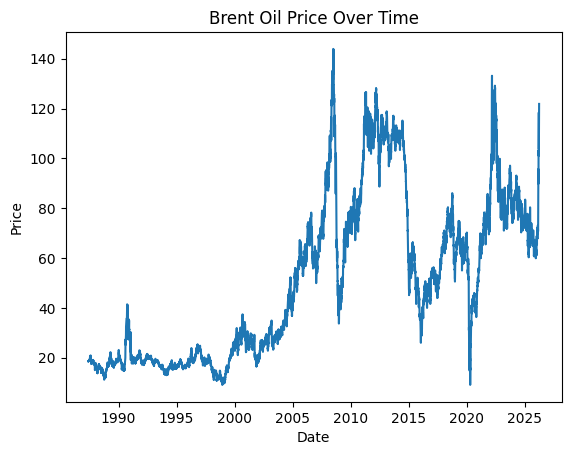

In [39]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["Date"], df["Price"])
plt.title("Brent Oil Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.savefig("Price_trend.png")
plt.show()

### Moving averages of a 7-day and 30-day period were calculated to smooth short-term fluctuations and highlight underlying trends in price movements.

In [40]:
df["MA_7"] = df["Price"].rolling(window=7).mean()
df["MA_30"] = df["Price"].rolling(window=30).mean()

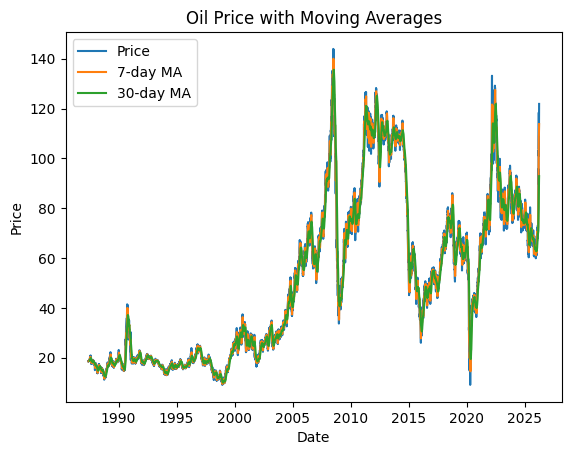

In [41]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df["Date"], df["Price"], label="Price")
plt.plot(df["Date"], df["MA_7"], label="7-day MA")
plt.plot(df["Date"], df["MA_30"], label="30-day MA")

plt.title("Oil Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.savefig("Moving_averages.png")

plt.show()

In [42]:
df["Volatility_30"] = df["Price"].rolling(window=30).std()

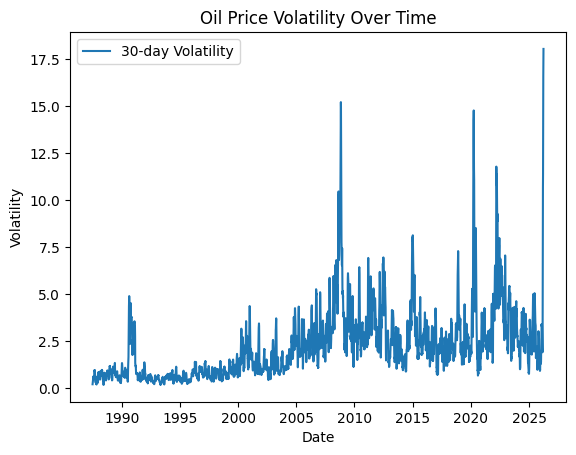

In [43]:
plt.figure()

plt.plot(df["Date"], df["Volatility_30"], label="30-day Volatility")

plt.title("Oil Price Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.legend()
plt.savefig("volatility.png")

plt.show()

## Volatility in oil prices closely reflects major global events and shifts in market conditions. From the analysis, the most significant spikes align with periods of economic and geopolitical stress, including the 2008 financial crisis, the 2020 COVID-19 demand shock, the 2021–2023 energy crisis, and most recently the 2026 Iran conflict, which has driven severe supply disruptions and market uncertainty.

### Daily returns were calculated to analyse relative price changes over time, providing a clearer view of market movements and short-term dynamics.

In [44]:
df["Returns"] = df["Price"].pct_change()

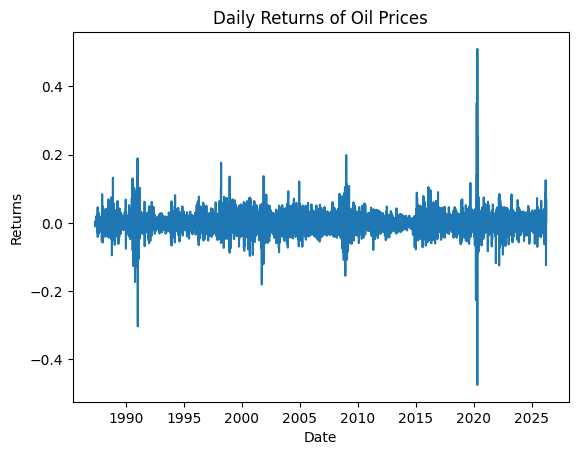

In [45]:
plt.figure()

plt.plot(df["Date"], df["Returns"])

plt.title("Daily Returns of Oil Prices")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.savefig("returns.png")
plt.show()

### Rolling volatility was calculated based on returns to measure periods of market instability and heightened uncertainty.

In [46]:
df["Volatility_Returns"] = df["Returns"].rolling(window=30).std()

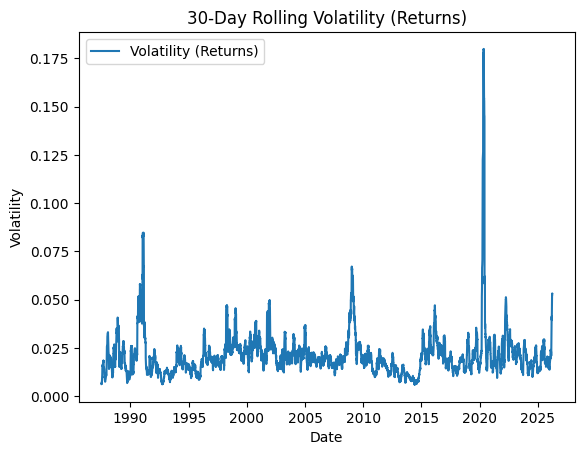

In [47]:
plt.figure()

plt.plot(df["Date"], df["Volatility_Returns"], label="Volatility (Returns)")

plt.title("30-Day Rolling Volatility (Returns)")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.legend()
plt.savefig("Volatility_returns")

plt.show()

### Periods of heightened return volatility clearly correspond to major external shocks, such as the 2008 financial crisis, COVID-19 in 2020, and recent geopolitical tensions in 2026. These spikes indicate sudden changes in market expectations and increased uncertainty, rather than gradual shifts in fundamentals.

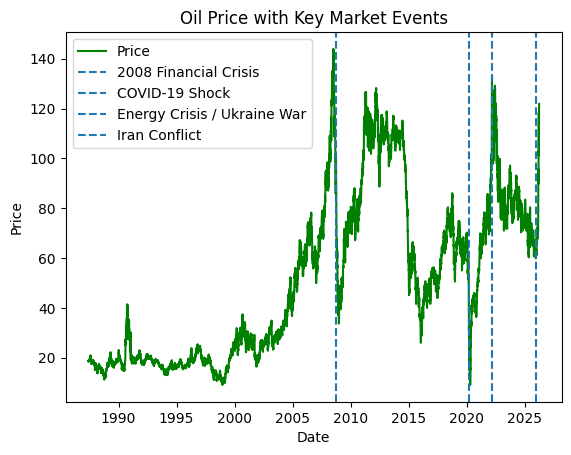

In [48]:
plt.figure()

plt.plot(df["Date"], df["Price"], color ="green", label="Price")

plt.title("Oil Price with Key Market Events")
plt.xlabel("Date")
plt.ylabel("Price")

plt.axvline(pd.to_datetime("2008-09-15"), linestyle="--", label="2008 Financial Crisis")
plt.axvline(pd.to_datetime("2020-03-01"), linestyle="--", label="COVID-19 Shock")
plt.axvline(pd.to_datetime("2022-02-24"), linestyle="--", label="Energy Crisis / Ukraine War")
plt.axvline(pd.to_datetime("2026-01-01"), linestyle="--", label="Iran Conflict")

plt.legend()
plt.show()